In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [4]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [5]:
df.fillna(df.mean(), inplace=True)

In [7]:
# Features (Input)
X = df.drop("target", axis=1)

# Target (Output)
y = df["target"]

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [11]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:, 1]

In [12]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:, 1]

In [13]:
from sklearn.model_selection import cross_val_score

lr_cv = cross_val_score(lr, X, y, cv=5)

rf_cv = cross_val_score(rf, X, y, cv=5)

print("Logistic Regression CV Mean:", lr_cv.mean())

print("Random Forest CV Mean:", rf_cv.mean())

Logistic Regression CV Mean: 0.8458536585365855
Random Forest CV Mean: 0.9970731707317073


In [14]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

In [15]:
print("----- Logistic Regression -----")

print("Accuracy :", accuracy_score(y_test, lr_pred))

print("Precision :", precision_score(y_test, lr_pred))

print("Recall :", recall_score(y_test, lr_pred))

print("F1 Score :", f1_score(y_test, lr_pred))

print("ROC AUC :", roc_auc_score(y_test, lr_prob))

----- Logistic Regression -----
Accuracy : 0.7951219512195122
Precision : 0.7563025210084033
Recall : 0.8737864077669902
F1 Score : 0.8108108108108109
ROC AUC : 0.8790215115172283


In [16]:
print("----- Random Forest -----")

print("Accuracy :", accuracy_score(y_test, rf_pred))

print("Precision :", precision_score(y_test, rf_pred))

print("Recall :", recall_score(y_test, rf_pred))

print("F1 Score :", f1_score(y_test, rf_pred))

print("ROC AUC :", roc_auc_score(y_test, rf_prob))

----- Random Forest -----
Accuracy : 0.9853658536585366
Precision : 1.0
Recall : 0.970873786407767
F1 Score : 0.9852216748768473
ROC AUC : 1.0


In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

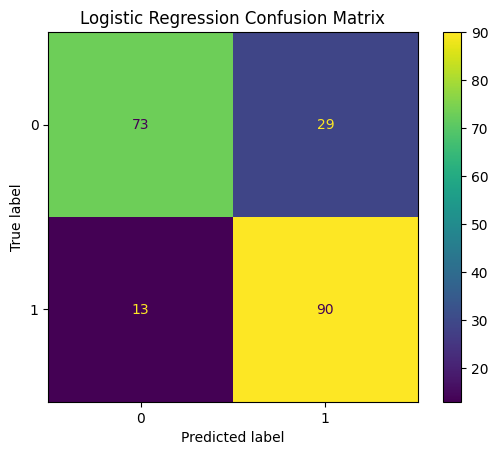

In [18]:
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

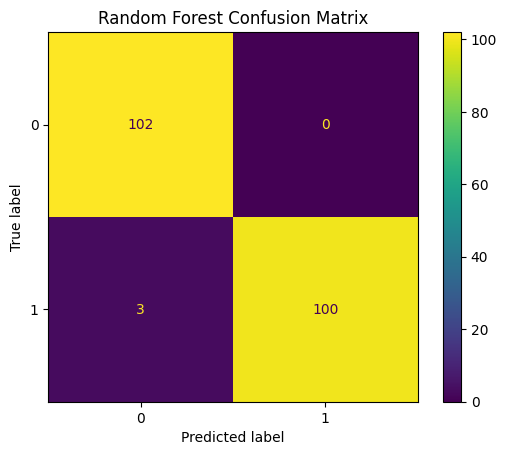

In [19]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [20]:
from sklearn.metrics import RocCurveDisplay

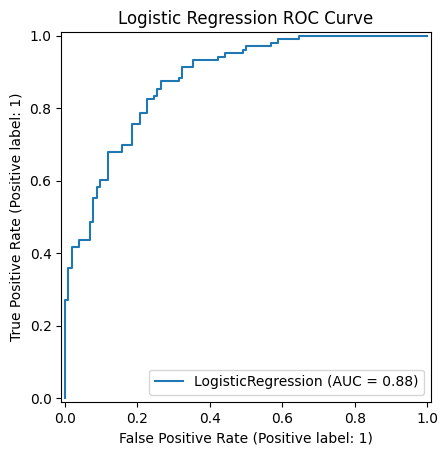

In [21]:
RocCurveDisplay.from_estimator(lr, X_test, y_test)

plt.title("Logistic Regression ROC Curve")

plt.show()

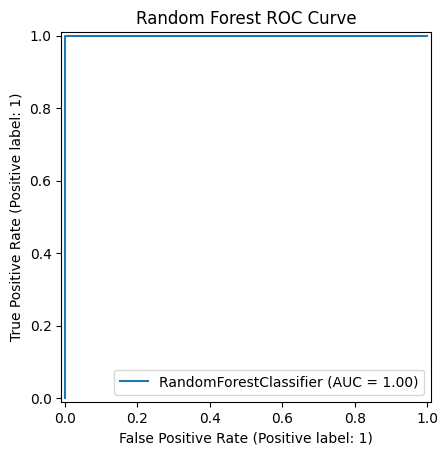

In [22]:
RocCurveDisplay.from_estimator(rf, X_test, y_test)

plt.title("Random Forest ROC Curve")

plt.show()

In [23]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob)
    ],
    "Cross Validation": [
        lr_cv.mean(),
        rf_cv.mean()
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC  \
0  Logistic Regression  0.795122   0.756303  0.873786  0.810811  0.879022   
1        Random Forest  0.985366   1.000000  0.970874  0.985222  1.000000   

   Cross Validation  
0          0.845854  
1          0.997073  
